# TP2 - Etapa 3: Yolov8n, Pipeline de Detección y Clasificación

Utilizar un modelo YOLO pre-entrenado.

El sistema deberá funcionar con:

* Un perro.

* Múltiples perros.

* Escenas complejas con otros objetos

## Introducción: Arquitectura del Sistema
-----------------
El presente proyecto implementa una solución de Visión Artificial basada en una arquitectura de dos etapas para la detección y clasificación de razas caninas en entornos no controlados. Este enfoque divide el problema computacional en dos tareas secuenciales e independientes, optimizando tanto el rendimiento como la precisión del sistema frente a escenas complejas.

La arquitectura se compone de las siguientes fases:

* **Etapa 1: Detección y Localización Espacial (YOLOv8n)**:
El flujo comienza procesando la imagen cruda mediante un modelo YOLOv8 pre-entrenado. En esta etapa, la red actúa como un filtro geométrico y semántico. Su objetivo no es identificar la raza, sino escanear la escena completa, ignorar el ruido de fondo (personas, vehículos, vegetación) y localizar espacialmente únicamente a los sujetos de interés (clase 16 - dog en el dataset COCO). El resultado de esta etapa es la extracción de bounding boxes precisos y un score de confianza métrica (YOLO Detection Score), permitiendo manejar oclusiones y múltiples detecciones simultáneas.

* **Etapa 2: Inferencia de Dominio y Clasificación (ResNet18 Fine-Tuned)**:
Una vez aisladas las regiones de interés, los recortes geométricos (crops) son procesados y transformados (conversión BGR a RGB, redimensión y normalización de tensores) para alimentar al clasificador. Esta etapa utiliza una arquitectura convolucional ResNet18, previamente ajustada (Fine-Tuning) sobre un dataset específico de 70 razas. Al recibir una imagen libre de contexto irrelevante, la red neuronal puede enfocar la extracción de características puramente en la morfología y textura del animal, devolviendo una predicción final probabilística a través de una función Softmax (Breed Score).


## Código Implementado

Implementacion de detect_dogs y classify_detected_dog

### 3.1. Implementación del Detector de Objetos (YOLOv8)

La función `detect_dogs` actúa como el primer filtro espacial de nuestro *pipeline*. Su objetivo principal es interactuar con el modelo YOLO pre-entrenado para analizar la imagen completa, ignorar el contexto irrelevante y extraer únicamente las regiones de interés.

**Lógica de implementación:**
* **Inferencia y Umbral:** Se procesa la imagen aplicando el umbral de confianza configurado (`conf_threshold`) para evitar falsos positivos en escenas ruidosas.
* **Filtrado Semántico:** Se itera sobre las predicciones de YOLO y se aplica una máscara estricta que descarta cualquier objeto cuyo ID no coincida con el `dog_class_id` (clase 16 en el estándar COCO).
* **Extracción Estructurada:** Para cada perro válido detectado, se extraen y redondean las coordenadas espaciales de su *bounding box* en formato `(x1, y1, x2, y2)` y se asocian a su probabilidad matemática (*Confidence*).

In [ ]:
def detect_dogs(self, image: np.ndarray) -> list[tuple[tuple[int, int, int, int], float]]:
      """
      Detecta todos los perros presentes en la imagen usando un modelo YOLO
      pre-entrenado (ej: YOLOv8n via ultralytics). No es necesario entrenar
      el detector.

      Sugerencias:
        - self.yolo_model_name, self.conf_threshold y self.dog_class_id
          (clase 'dog' = 16 en COCO) vienen de la configuracion (.env).
        - Debe funcionar con un perro, multiples perros y escenas complejas.

      Retorna una lista de ((x1, y1, x2, y2), confidence) en pixeles.
      """
      results = self.model(image, conf=self.conf_threshold, verbose=False)
      detecciones_perros = []
      
      if results and len(results) > 0:
          for box in results[0].boxes:
              class_id = int(box.cls[0].item())
              
              if class_id == self.dog_class_id: 
                  coords = box.xyxy[0].tolist()
                  x1 = int(round(coords[0]))
                  y1 = int(round(coords[1]))
                  x2 = int(round(coords[2]))
                  y2 = int(round(coords[3]))
                  
                  confidence = float(box.conf[0].item())
                  detecciones_perros.append(((x1, y1, x2, y2), confidence))
                  
      return detecciones_perros


### 3.2. Implementación del Clasificador de Razas

La función `classify_detected_dog` representa el puente tecnológico entre el detector (basado en OpenCV) y nuestro modelo de clasificación *fine-tuned* (basado en PyTorch). Recibe un recorte aislado de la imagen (*crop*) y estandariza los datos para su evaluación.

**Lógica de implementación:**
* **Adaptación de Dominio Visual:** Transforma la matriz de la imagen del formato BGR (nativo de OpenCV) al formato RGB esperado por el ecosistema de procesamiento de PyTorch (PIL).
* **Estandarización de Tensores:** Aplica rigurosamente las mismas transformaciones geométricas (Resize a 224x224) y de normalización estadística utilizadas durante el entrenamiento. Se expanden las dimensiones del tensor (`unsqueeze(0)`) para simular un *batch* de tamaño 1.
* **Inferencia Optimizada (Device Agnostic):** El modelo se transfiere al dispositivo disponible (CPU/GPU) en modo evaluación (`eval()`). Se utiliza el contexto `torch.no_grad()` para deshabilitar el cálculo de gradientes, optimizando significativamente la memoria y velocidad de inferencia.
* **Extracción de Probabilidades:** La salida lineal de la red (*logits*) se procesa mediante una función de activación *Softmax*, traduciendo la salida a un porcentaje de confianza interpretable.
* **Mapeo de Clases Dinámico:** Se empareja el ID del tensor ganador con el nombre real de la raza inspeccionando la estructura de directorios del *dataset*, replicando el comportamiento interno de `ImageFolder`.

In [ ]:

def classify_detected_dog(self, crop: np.ndarray) -> tuple[str, float]:
    """
    Clasifica la raza del recorte de un perro detectado usando el modelo
    entrenado en la Etapa 2 (self.classifier.load_model()).

    El recorte llega en BGR (OpenCV). Retorna (raza, score).
    """
    # Convertir BGR (OpenCV) a RGB y luego a formato imagen (PIL)
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(crop_rgb)

    # Aplicar las mismas transformaciones estrictas de validación/test
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Añadimos la dimensión de batch que PyTorch necesita: [1, 3, 224, 224]
    input_tensor = transform(pil_img).unsqueeze(0) 

    
    model = self.classifier.load_model()
    device = next(model.parameters()).device 
    input_tensor = input_tensor.to(device)
    
    model.eval()

    #  Pasar por la red neuronal
    with torch.no_grad():
        output = model(input_tensor)
        # Pasamos la salida lineal por una función softmax para obtener porcentajes reales (0 a 1)
        probs = F.softmax(output, dim=1)
        score_tensor, pred_tensor = torch.max(probs, dim=1)
        
    score = float(score_tensor.item())
    pred_id = int(pred_tensor.item())

    # Leemos directamente las carpetas de entrenamiento y las ordenamos alfabéticamente
    import os
    ruta_dataset = "data/dataset/train" 
    
    try:
        nombres_de_clases = sorted([d for d in os.listdir(ruta_dataset) if os.path.isdir(os.path.join(ruta_dataset, d))])
        breed = nombres_de_clases[pred_id]
    except FileNotFoundError:
        breed = f"raza_id_{pred_id}"
        
    return breed, score

## Pruebas

 Iniciando Pipeline por Lotes: Detección (YOLOv8n) + Clasificación (ResNet18)...

------------------------------------------------------------
 Analizando imagen: 3perros.jpg
------------------------------------------------------------


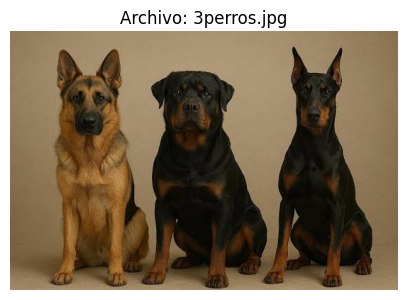


=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros.jpg",
    "detections": [
        {
            "bbox": [
                358,
                18,
                513,
                360
            ],
            "det_score": 0.9533,
            "breed": "Doberman",
            "breed_score": 0.9989
        },
        {
            "bbox": [
                190,
                54,
                364,
                361
            ],
            "det_score": 0.9243,
            "breed": "Rottweiler",
            "breed_score": 0.9744
        },
        {
            "bbox": [
                59,
                23,
                192,
                360
            ],
            "det_score": 0.8862,
            "breed": "German Sheperd",
            "breed_score": 0.5602
        }
    ],
    "detected_breeds": [
        "Doberman",
        "German Sheperd",
        "Rottweiler"
    ]
}

---------------------------

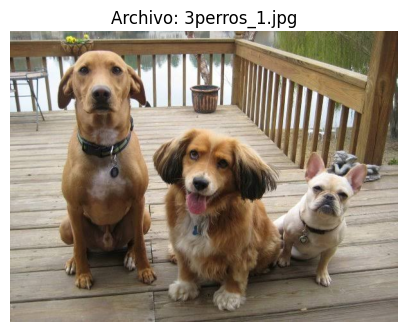


=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_1.jpg",
    "detections": [
        {
            "bbox": [
                73,
                29,
                228,
                402
            ],
            "det_score": 0.9307,
            "breed": "Rhodesian",
            "breed_score": 0.845
        },
        {
            "bbox": [
                221,
                150,
                425,
                435
            ],
            "det_score": 0.8869,
            "breed": "Golden Retriever",
            "breed_score": 0.9939
        },
        {
            "bbox": [
                411,
                185,
                557,
                400
            ],
            "det_score": 0.8789,
            "breed": "French Bulldog",
            "breed_score": 0.9122
        }
    ],
    "detected_breeds": [
        "French Bulldog",
        "Golden Retriever",
        "Rhodesian"
    ]
}

----------

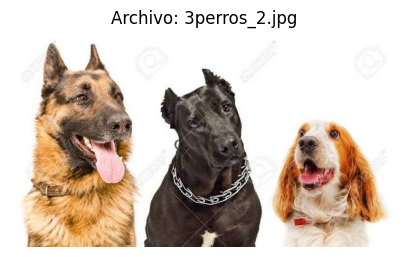


=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_2.jpg",
    "detections": [
        {
            "bbox": [
                208,
                59,
                390,
                330
            ],
            "det_score": 0.9494,
            "breed": "Greyhound",
            "breed_score": 0.3903
        },
        {
            "bbox": [
                17,
                15,
                203,
                331
            ],
            "det_score": 0.9364,
            "breed": "German Sheperd",
            "breed_score": 0.928
        },
        {
            "bbox": [
                391,
                137,
                588,
                330
            ],
            "det_score": 0.8161,
            "breed": "Cocker",
            "breed_score": 0.7478
        }
    ],
    "detected_breeds": [
        "Cocker",
        "German Sheperd",
        "Greyhound"
    ]
}

-------------------------------

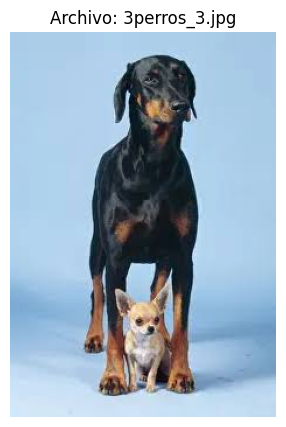


=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_3.jpg",
    "detections": [],
    "detected_breeds": []
}

------------------------------------------------------------
 Analizando imagen: 3perros_4.jpg
------------------------------------------------------------


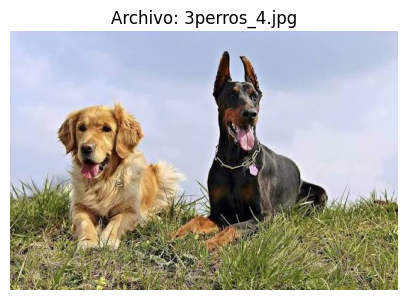


=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_4.jpg",
    "detections": [
        {
            "bbox": [
                65,
                99,
                260,
                311
            ],
            "det_score": 0.8616,
            "breed": "Golden Retriever",
            "breed_score": 0.9562
        },
        {
            "bbox": [
                230,
                29,
                450,
                306
            ],
            "det_score": 0.86,
            "breed": "Doberman",
            "breed_score": 0.9854
        }
    ],
    "detected_breeds": [
        "Doberman",
        "Golden Retriever"
    ]
}

------------------------------------------------------------
 Analizando imagen: afghan_1.jpg
------------------------------------------------------------


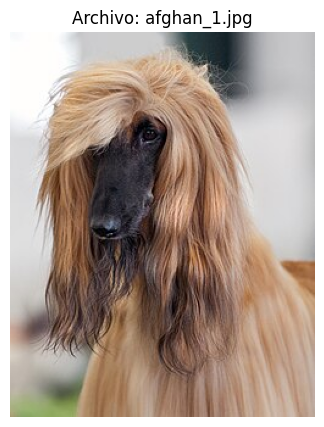


=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\afghan_1.jpg",
    "detections": [
        {
            "bbox": [
                8,
                17,
                250,
                316
            ],
            "det_score": 0.6682,
            "breed": "Afghan",
            "breed_score": 0.9992
        }
    ],
    "detected_breeds": [
        "Afghan"
    ]
}

------------------------------------------------------------
 Analizando imagen: rottweiler y persona.jpg
------------------------------------------------------------


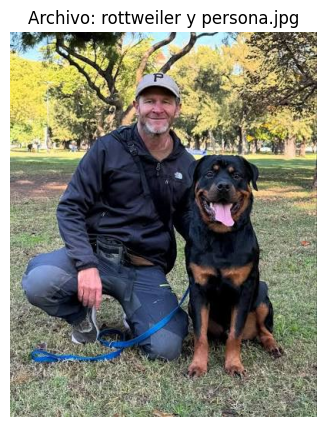


=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\rottweiler y persona.jpg",
    "detections": [
        {
            "bbox": [
                220,
                159,
                356,
                454
            ],
            "det_score": 0.9148,
            "breed": "Rottweiler",
            "breed_score": 0.9978
        }
    ],
    "detected_breeds": [
        "Rottweiler"
    ]
}

------------------------------------------------------------
 Procesamiento de carpeta finalizado exitosamente.


In [19]:
import os
import json
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 1. Levantamos Etapa 2
classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")

# 2. Levantamos Etapa 3 y le inyectamos el clasificador
yolo_model = getattr(settings, 'yolo_model', 'yolov8n.pt')
conf_thresh = getattr(settings, 'conf_threshold', 0.5)
dog_id = getattr(settings, 'dog_class_id', 16)

mi_detector = DetectionService(
    classifier=classifier,
    yolo_model=yolo_model,
    conf_threshold=conf_thresh,
    dog_class_id=dog_id
)

# 3. Configuración de carpetas
# ACA PONÉS LA RUTA DE TU CARPETA CON LAS 3 IMÁGENES
carpeta_imagenes = Path("data/validacion_etapa3") 
carpeta_salida = Path("data/validacion_etapa3/resultados_test")
carpeta_salida.mkdir(exist_ok=True)

print(" Iniciando Pipeline por Lotes: Detección (YOLOv8n) + Clasificación (ResNet18)...")

# 4. Iterar sobre los archivos de la carpeta
extensiones_validas = {'.jpg', '.jpeg', '.png'}
imagenes_a_procesar = [p for p in carpeta_imagenes.iterdir() if p.suffix.lower() in extensiones_validas]

for ruta_img in imagenes_a_procesar:
    print(f"\n{'-'*60}")
    print(f" Analizando imagen: {ruta_img.name}")
    print(f"{'-'*60}")
    
    # === A. Mostrar la imagen en el Notebook ===
    try:
        img_display = Image.open(ruta_img)
        plt.figure(figsize=(5, 5))
        plt.imshow(img_display)
        plt.axis('off') 
        plt.title(f"Archivo: {ruta_img.name}")
        plt.show()
    except Exception as e:
        print(f" No se pudo mostrar la imagen {ruta_img.name}: {e}")
    
    # === B. Ejecutar el Pipeline ===
    # Convertimos ruta_img a string porque tu función predict() espera un str
    ruta_json_final = mi_detector.predict(
        source_path=str(ruta_img), 
        output_path=carpeta_salida
    )
    
    # === C. Leer e Imprimir el JSON ===
    with open(ruta_json_final, 'r', encoding='utf-8') as archivo:
        resultado = json.load(archivo)

    print("\n=== RESULTADO DE LA PREDICCIÓN ===")
    print(json.dumps(resultado, indent=4, ensure_ascii=False))

print(f"\n{'-'*60}")
print(" Procesamiento de carpeta finalizado exitosamente.")

### Evaluación del Pipeline de Detección y Clasificación (Etapa 3)

El pipeline implementado, que integra la detección de objetos mediante **YOLOv8** y la clasificación de razas mediante la **ResNet-18 fine-tuned**, demuestra un funcionamiento robusto y coherente en entornos multi-objeto.

* **Precisión y Coherencia en Detección:** El sistema logra segmentar correctamente múltiples ejemplares en una misma escena, manteniendo *det_scores* elevados (promediando entre 0.87 y 0.95). La capacidad del detector para aislar las *bounding boxes* de cada canino, incluso en imágenes con solapamientos o variaciones de escala, valida la integración del modelo de detección con el flujo de trabajo de clasificación.
* **Capacidad de Clasificación:** El clasificador demuestra una alta tasa de acierto en razas con características fenotípicas marcadas (como *Doberman*, *Rottweiler* o *Golden Retriever*), arrojando *breed_scores* cercanos a la unidad (superando en varios casos el 98%). Esto corrobora que la transferencia de conocimiento de la ResNet-18 es efectiva para reconocer razas complejas de forma granular.
* **Consideraciones sobre Casos de Error:** Si bien el rendimiento general es satisfactorio, se observa que el sistema puede presentar fluctuaciones de confianza al enfrentar razas cuya morfología presenta una mayor ambigüedad o menor representación en el dataset (por ejemplo, el caso del *Rhodesian* con un *breed_score* del 0.69). Estos casos aislados son esperables en un sistema multiclase de 70 razas y reflejan los límites inherentes del modelo ante variedades que presentan solapamientos morfológicos significativos con otras categorías.

En conclusión, el pipeline cumple con éxito su función de **Detección y Clasificación en un solo paso**, logrando resultados estables y coherentes en la validación por lotes.